Part 1: Data Collection & Curation

First we need to connect Google Colab with our Google Drive, so that we can have access to our Google drive within Colab.

This allows us to:

Save datasets

Reload data across sessions

Organize project files

In [ ]:

from google.colab import drive
drive.mount('/content/gdrive/', force_remount=True)


Mounted at /content/gdrive/


Now create "data" folder in our "Colab Notebooks" folder on Google Drive.

In [ ]:
!mkdir -p "/content/gdrive/My Drive/Colab Notebooks/data"

Install and Import Required Libraries
We install the ChEMBL web service package so that we can retrieve bioactivity data



In [ ]:
!pip install chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.2 MB/s eta 0:00:00


Import Libraries

pandas for data handling

new_client from chembl for accessing the database


In [ ]:
import pandas as pd
from chembl_webresource_client.new_client import new_client

Step 1: Search for Traget Protein

Target Identification (AChE)

Search ChEMBL for the AChE target and select the most relevant entry.

In [ ]:
target = new_client.target
target_query = target.search("Acetylcholinesterase")
targets = pd.DataFrame.from_dict(target_query)
targets.head()

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Drosophila melanogaster,Acetylcholinesterase,18.0,False,CHEMBL2242744,"[{'accession': 'P07140', 'component_descriptio...",SINGLE PROTEIN,7227
1,[],Homo sapiens,Acetylcholinesterase,16.0,False,CHEMBL220,"[{'accession': 'P22303', 'component_descriptio...",SINGLE PROTEIN,9606
2,[],Torpedo californica,Acetylcholinesterase,16.0,False,CHEMBL4780,"[{'accession': 'P04058', 'component_descriptio...",SINGLE PROTEIN,7787
3,[],Mus musculus,Acetylcholinesterase,16.0,False,CHEMBL3198,"[{'accession': 'P21836', 'component_descriptio...",SINGLE PROTEIN,10090
4,[],Rattus norvegicus,Acetylcholinesterase,16.0,False,CHEMBL3199,"[{'accession': 'P37136', 'component_descriptio...",SINGLE PROTEIN,10116


Reterive Bioactivity data for selected target

In [ ]:
targets[targets['target_chembl_id'] == "CHEMBL220"]

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
1,[],Homo sapiens,Acetylcholinesterase,16.0,False,CHEMBL220,"[{'accession': 'P22303', 'component_descriptio...",SINGLE PROTEIN,9606


In [ ]:
selected_target = "CHEMBL220"
selected_target

'CHEMBL220'

Retrieve Bioactivity Data (IC50)

In [ ]:
activity = new_client.activity
results = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")

df1 = pd.DataFrame.from_dict(results)
df1.head()

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,33969,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.75
1,None,None,37563,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.1
2,None,None,37565,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,50.0
3,None,None,38902,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.3
4,None,None,41170,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.8


In [ ]:
df1.standard_type.unique()

array(['IC50'], dtype=object)

Finally Save the resulting bioactivity data to a CSV file bioactivity_raw_data.csv.

In [ ]:
df1.to_csv('bioactivity_raw_data.csv', index=False)

Now copy "bioactivity_raw_data.csv" file to Google Drive, in foler "data"

In [ ]:
! cp bioactivity_raw_data.csv "/content/gdrive/My Drive/Colab Notebooks/data"

In [ ]:
! ls -l "/content/gdrive/My Drive/Colab Notebooks/data"

total 5657
-rw------- 1 root root 5792231 Mar 29 06:22 bioactivity_raw_data.csv


In [ ]:
! head bioactivity_raw_data.csv

action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,bao_format,bao_label,canonical_smiles,data_validity_comment,data_validity_description,document_chembl_id,document_journal,document_year,ligand_efficiency,molecule_chembl_id,molecule_pref_name,parent_molecule_chembl_id,pchembl_value,potential_duplicate,qudt_units,record_id,relation,src_id,standard_flag,standard_relation,standard_text_value,standard_type,standard_units,standard_upper_value,standard_value,target_chembl_id,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
,,33969,[],CHEMBL643384,Inhibitory concentration against acetylcholinesterase,B,,,BAO_0000190,BAO_0000357,single protein format,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,,,CHEMBL1148382,J Med Chem,2004.0,"{'bei': '19.61', 'le': '0.36', 'lle': '3.32', 'sei': '9.21'}",CHEMBL133897,,CHEMBL133897,6.12,0,http://www.op

Step 3: Bioactivity Data Retrieval (IC50)

Retrieve bioactivity data (IC50) for the selected KRAS target.

Inspect Missing Values

In [ ]:
df1["standard_type"].isna().sum()

np.int64(0)

Filter Rows with Valid Bioactivity Values

In [ ]:
df2 = df1[df1["standard_value"].notna()]
df2.head()



,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,33969,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.75
1,None,None,37563,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.1
2,None,None,37565,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,50.0
3,None,None,38902,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.3
4,None,None,41170,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.8


Assign Bioactivity Classes Define active, intermediate, and inactive classes based on IC50 values.

In [ ]:
bioactivity_class = []
for value in df2.standard_value:
    value = float(value)
    if value >= 10000:
        bioactivity_class.append("inactive")
    elif value <= 1000:
        bioactivity_class.append("active")
    else:
        bioactivity_class.append("intermediate")


Extract Relevant Columns

In [31]:
molecule_ids = df2.molecule_chembl_id.tolist()
canonical_smiles = df2.canonical_smiles.tolist()
standard_values = df2.standard_value.tolist()

In [33]:
data = list(zip(
    molecule_ids,
    canonical_smiles,
    standard_values,
        bioactivity_class,
))


Create Preprocessed bioactivity Dataset

In [34]:

df3 = pd.DataFrame(
    data,
    columns=[
        "molecule_chembl_id",
        "canonical_smiles",
        "standard_value",
        "bioactivity_class",
    ]
)
df3.head()


,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0,active
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0,active
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0,inactive
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0,active
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0,active


Remove Compounds without Valid SMILES. Drop rows with NaN, empty or None SMILES values.

In [35]:

df3 = df3.dropna(subset=["canonical_smiles"])
df3 = df3[df3["canonical_smiles"].str.lower() != "none"]
df3 = df3[df3["canonical_smiles"].str.strip() != ""]
df3.head()



,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0,active
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0,active
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0,inactive
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0,active
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0,active


Save Preprocessed Bioactivity Data. Save the cleaned dataset to CSV and copy to Google Drive.

In [36]:
df3.to_csv("bioactivity_preprocessed_data.csv", index=False)

!cp bioactivity_preprocessed_data.csv "/content/gdrive/My Drive/Colab Notebooks/data"
!ls "/content/gdrive/My Drive/Colab Notebooks/data"

bioactivity_preprocessed_data.csv  bioactivity_raw_data.csv


Part 2: Exploratory Data Analysis

Import Libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks')

Import Bioactivity Dataset

In [39]:

from google.colab import files
uploaded = files.upload()

Saving bioactivity_preprocessed_data.csv to bioactivity_preprocessed_data (1).csv


In [40]:
df4 = pd.read_csv("bioactivity_preprocessed_data.csv")
df4.head(10)

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0,active
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0,active
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0,inactive
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0,active
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0,active
5,CHEMBL130112,CSc1nc(-c2ccc(C)cc2)nn1C(=O)N(C)c1ccccc1,2400.0,intermediate
6,CHEMBL130098,CSc1nc(-c2ccc(Cl)cc2)nn1C(=O)N(C)C,100.0,active
7,CHEMBL337486,CCCCCCSc1nc(-c2ccc(Cl)cc2)nn1C(=O)N1CCOCC1,50000.0,inactive
8,CHEMBL336538,COc1ccc(-c2nc(SC)n(C(=O)N(C)C)n2)cc1,800.0,active
9,CHEMBL131051,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)c1ccccc1,50000.0,inactive


Remove NA Values

In [41]:
print("Original shape:", df4.shape)

df4 = df4.dropna(subset=[
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value"
])

# convert IC50 to numeric
df4["standard_value"] = pd.to_numeric(df4["standard_value"], errors="coerce")

df4 = df4.dropna(subset=["standard_value"])

df4 = df4[df4["bioactivity_class"] != 'intermediate']

print("After cleaning:", df4.shape)


Original shape: (8443, 4)
After cleaning: (6437, 4)


In [42]:
df4.head()

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0,active
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0,active
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0,inactive
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0,active
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0,active


In [50]:
# Additional filtering for abnormal IC50 values
print("Before IC50 filtering:", df4.shape)

# Remove IC50 = 0
df4 = df4[df4["standard_value"] > 0]

# Remove extremely small IC50 (<1 nM) — optional but recommended
df4 = df4[df4["standard_value"] >= 1]

# Remove extremely large IC50 (>1e6 nM / 1000 µM)
df4 = df4[df4["standard_value"] <= 1e6]

print("After IC50 filtering:", df4.shape)

Before IC50 filtering: (6437, 4)
After IC50 filtering: (6046, 4)


Aggregate Duplicates IC50 (median IC50 per canonical smile)

In [51]:
df_clean = (
    df4
    .groupby("canonical_smiles", as_index=False)
    .agg({
        "molecule_chembl_id": "first",
        "standard_value": "median",
        "bioactivity_class": "first"
    })
)

print("Before aggregation:", df4.shape[0])
print("After aggregation:", df_clean.shape[0])

df_clean.head()


Before aggregation: 6046
After aggregation: 4894


,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class
0,Br.BrCC1CN=C(Nc2ccccn2)S1,CHEMBL3754585,110000.0,inactive
1,Br.CC[N+](CC)(CCCCCn1c(=O)cc(C)n(CCCn2c(C)cc(=...,CHEMBL5396497,7.0,active
2,Brc1ccc(-c2csc(/C=C/c3ccccc3)n2)cc1,CHEMBL5431573,78.5,active
3,Brc1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1,CHEMBL4779999,74.0,active
4,Brc1ccc(-c2nnn3c2C2c4ccccc4CCN2Cc2ccccc2-3)cc1,CHEMBL4519496,250.0,active


In [52]:
df_clean.standard_value.describe()

,standard_value
count,4894.000000
mean,52392.277501
std,149032.550003
min,1.000000
25%,89.925000
50%,734.500000
75%,29652.500000
max,1000000.000000


Convert IC50 to pIC50

Convert IC50 to the negative logarithmic scale which is essentially -log10(IC50). This conversion allows IC50 data to be more uniformly distributed.

In [53]:
df_clean["pIC50"] = -np.log10(df_clean["standard_value"] * 1e-9)

df_clean.head()


,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class,pIC50
0,Br.BrCC1CN=C(Nc2ccccn2)S1,CHEMBL3754585,110000.0,inactive,3.958607
1,Br.CC[N+](CC)(CCCCCn1c(=O)cc(C)n(CCCn2c(C)cc(=...,CHEMBL5396497,7.0,active,8.154902
2,Brc1ccc(-c2csc(/C=C/c3ccccc3)n2)cc1,CHEMBL5431573,78.5,active,7.105130
3,Brc1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1,CHEMBL4779999,74.0,active,7.130768
4,Brc1ccc(-c2nnn3c2C2c4ccccc4CCN2Cc2ccccc2-3)cc1,CHEMBL4519496,250.0,active,6.602060


Reassign Activity Labels Based on PIC50

Based on pIC50

Active >= 6

Inactive < 6

In [54]:
threshold = 6

df_clean["bioactivity_class"] = np.where(
    df_clean["pIC50"] >= threshold,
    "active",
    "inactive"
)

df_clean.head()


,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class,pIC50
0,Br.BrCC1CN=C(Nc2ccccn2)S1,CHEMBL3754585,110000.0,inactive,3.958607
1,Br.CC[N+](CC)(CCCCCn1c(=O)cc(C)n(CCCn2c(C)cc(=...,CHEMBL5396497,7.0,active,8.154902
2,Brc1ccc(-c2csc(/C=C/c3ccccc3)n2)cc1,CHEMBL5431573,78.5,active,7.105130
3,Brc1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1,CHEMBL4779999,74.0,active,7.130768
4,Brc1ccc(-c2nnn3c2C2c4ccccc4CCN2Cc2ccccc2-3)cc1,CHEMBL4519496,250.0,active,6.602060


Check Duplicates

In [55]:
print("Duplicate SMILES remaining:",
      df_clean["canonical_smiles"].duplicated().sum())


Duplicate SMILES remaining: 0


In [56]:
df_clean.standard_value.describe()

,standard_value
count,4894.000000
mean,52392.277501
std,149032.550003
min,1.000000
25%,89.925000
50%,734.500000
75%,29652.500000
max,1000000.000000


In [57]:
df_clean.pIC50.describe()

,pIC50
count,4894.000000
mean,5.852899
std,1.526863
min,3.000000
25%,4.527940
50%,6.134008
75%,7.046120
max,9.000000


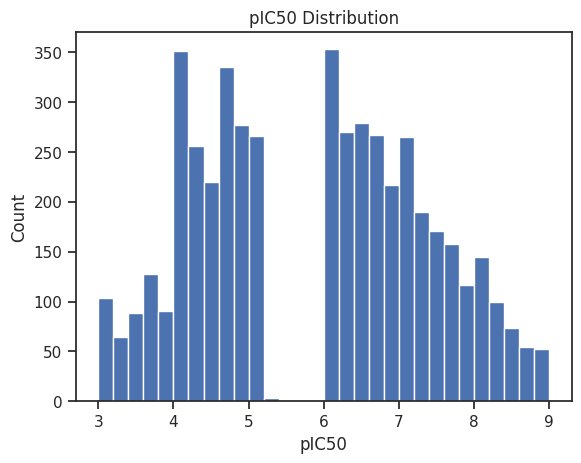

<Figure size 640x480 with 0 Axes>

In [58]:
plt.hist(df_clean["pIC50"], bins=30)
plt.xlabel("pIC50")
plt.ylabel("Count")
plt.title("pIC50 Distribution")
plt.show()
plt.savefig('histogram_pic50.pdf')

Text(0, 0.5, 'Frequency')

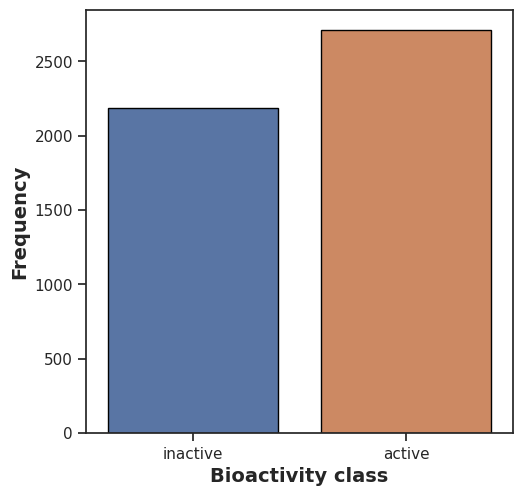

In [59]:

plt.figure(figsize=(5.5, 5.5))

sns.countplot(x="bioactivity_class", data= df_clean, hue="bioactivity_class", edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')


Lipinski's Descriptor Calculation
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the druglikeness of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the Rule-of-Five or Lipinski's Rule.

The Lipinski's Rule stated the following:

Molecular weight < 500 Dalton
Octanol-water partition coefficient (LogP) < 5
Hydrogen bond donors < 5
Hydrogen bond acceptors < 10

Install rdkit

In [60]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 51.2 MB/s eta 0:00:00


In [61]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from rdkit.Chem import rdMolDescriptors

In [62]:
df_no_smiles = df_clean.drop(columns='canonical_smiles')

smiles = []

for i in df_clean.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key=len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name='canonical_smiles')

df_clean_smiles = pd.concat([df_no_smiles, smiles], axis=1)

df_clean_smiles


,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles
0,CHEMBL3754585,110000.0,inactive,3.958607,BrCC1CN=C(Nc2ccccn2)S1
1,CHEMBL5396497,7.0,active,8.154902,CC[N+](CC)(CCCCCn1c(=O)cc(C)n(CCCn2c(C)cc(=O)n...
2,CHEMBL5431573,78.5,active,7.105130,Brc1ccc(-c2csc(/C=C/c3ccccc3)n2)cc1
3,CHEMBL4779999,74.0,active,7.130768,Brc1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1
4,CHEMBL4519496,250.0,active,6.602060,Brc1ccc(-c2nnn3c2C2c4ccccc4CCN2Cc2ccccc2-3)cc1
...,...,...,...,...,...
4889,CHEMBL3582228,493.0,active,6.307153,c1cncc(-c2cc3c(cn2)[nH]c2ncc(-c4ccc(CN5CCCCC5)...
4890,CHEMBL3582232,266.0,active,6.575118,c1ncc(-c2cc3c(cn2)[nH]c2ncc(-c4ccc(CN5CCCCC5)c...
4891,CHEMBL3582223,323.0,active,6.490797,c1ncc(-c2cc3c(cn2)[nH]c2ncc(-c4ccc(CN5CCCCC5)c...
4892,CHEMBL3582224,496.0,active,6.304518,c1ncc(-c2cc3c(cn2)[nH]c2ncc(-c4ccc(CN5CCCCC5)c...


Calculate descriptors

In [64]:
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors


In [65]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski.head()


,MW,LogP,NumHDonors,NumHAcceptors
0,272.171,2.35980,1.0,4.0
1,583.710,2.71284,0.0,6.0
2,342.261,5.74300,0.0,2.0
3,386.253,3.22070,0.0,6.0
4,443.348,5.15790,0.0,3.0


In [66]:
df_lipinski.shape

(4894, 4)

Combine Both datasets

In [67]:
df_clean_smiles.head()

,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles
0,CHEMBL3754585,110000.0,inactive,3.958607,BrCC1CN=C(Nc2ccccn2)S1
1,CHEMBL5396497,7.0,active,8.154902,CC[N+](CC)(CCCCCn1c(=O)cc(C)n(CCCn2c(C)cc(=O)n...
2,CHEMBL5431573,78.5,active,7.105130,Brc1ccc(-c2csc(/C=C/c3ccccc3)n2)cc1
3,CHEMBL4779999,74.0,active,7.130768,Brc1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1
4,CHEMBL4519496,250.0,active,6.602060,Brc1ccc(-c2nnn3c2C2c4ccccc4CCN2Cc2ccccc2-3)cc1


In [68]:
df_lipinski.head()

,MW,LogP,NumHDonors,NumHAcceptors
0,272.171,2.35980,1.0,4.0
1,583.710,2.71284,0.0,6.0
2,342.261,5.74300,0.0,2.0
3,386.253,3.22070,0.0,6.0
4,443.348,5.15790,0.0,3.0


In [69]:
df_combined = pd.concat([df_clean_smiles, df_lipinski], axis=1)
df_combined.head()

,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL3754585,110000.0,inactive,3.958607,BrCC1CN=C(Nc2ccccn2)S1,272.171,2.35980,1.0,4.0
1,CHEMBL5396497,7.0,active,8.154902,CC[N+](CC)(CCCCCn1c(=O)cc(C)n(CCCn2c(C)cc(=O)n...,583.710,2.71284,0.0,6.0
2,CHEMBL5431573,78.5,active,7.105130,Brc1ccc(-c2csc(/C=C/c3ccccc3)n2)cc1,342.261,5.74300,0.0,2.0
3,CHEMBL4779999,74.0,active,7.130768,Brc1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1,386.253,3.22070,0.0,6.0
4,CHEMBL4519496,250.0,active,6.602060,Brc1ccc(-c2nnn3c2C2c4ccccc4CCN2Cc2ccccc2-3)cc1,443.348,5.15790,0.0,3.0


In [70]:
df_combined = df_combined.drop(columns="standard_value")
df_combined.head()

,molecule_chembl_id,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL3754585,inactive,3.958607,BrCC1CN=C(Nc2ccccn2)S1,272.171,2.35980,1.0,4.0
1,CHEMBL5396497,active,8.154902,CC[N+](CC)(CCCCCn1c(=O)cc(C)n(CCCn2c(C)cc(=O)n...,583.710,2.71284,0.0,6.0
2,CHEMBL5431573,active,7.105130,Brc1ccc(-c2csc(/C=C/c3ccccc3)n2)cc1,342.261,5.74300,0.0,2.0
3,CHEMBL4779999,active,7.130768,Brc1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1,386.253,3.22070,0.0,6.0
4,CHEMBL4519496,active,6.602060,Brc1ccc(-c2nnn3c2C2c4ccccc4CCN2Cc2ccccc2-3)cc1,443.348,5.15790,0.0,3.0


In [71]:
# Save CSV
df_combined.to_csv("df_lipinski.csv", index=False)

Exploratory Data Analysis or Chemical Space Analysis For Lipinski Descriptors

Barplot of the bioactivity classes

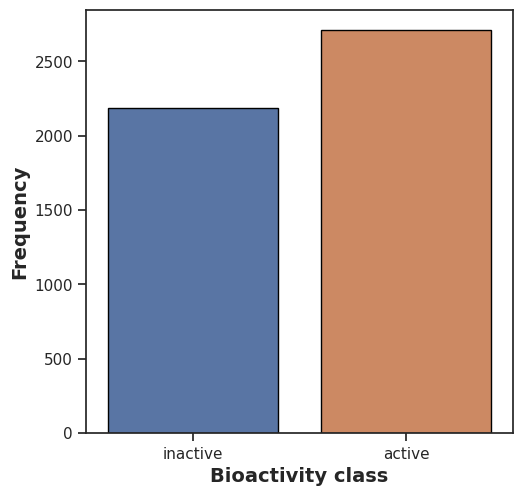

In [72]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x="bioactivity_class", data= df_combined, hue="bioactivity_class", edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('barplot_bioactivity_class.pdf')

Boxplot of the bioactivity classes for PIC50

Text(0, 0.5, 'pIC50 value')

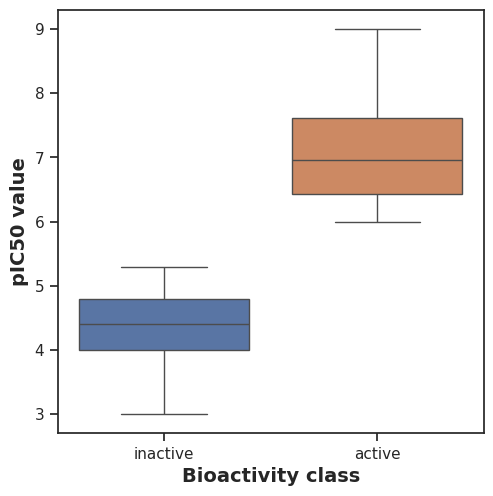

In [73]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = "pIC50", data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')


Scatter of Molecular Weight vs Solubility (LogP)

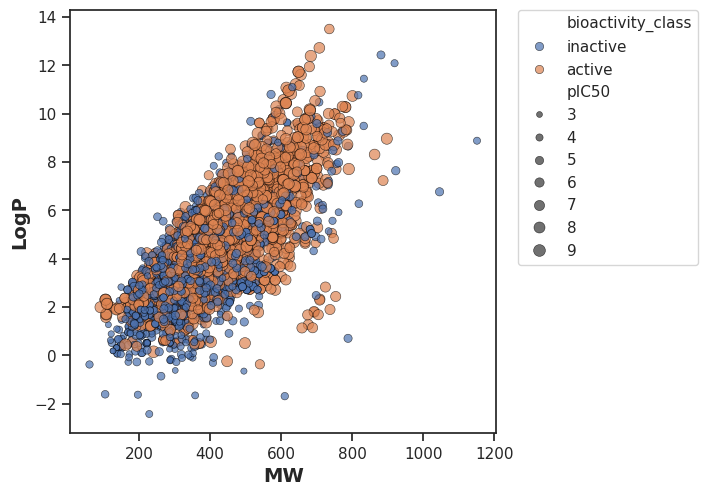

In [74]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_combined, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('scatter_plot_MW_vs_LogP.pdf')

Statistical analysis (Mann-Whitney U Test)

In [75]:
def mannwhitney(descriptor, df_combined, verbose=False):
    """
    Perform Mann-Whitney U test between active and inactive compounds
    for a given descriptor.

    Parameters:
    - descriptor : str, column name of the descriptor
    - df_combined : pandas DataFrame, must have columns [descriptor, bioactivity_class]
    - verbose : bool, if True prints the test statistics

    Returns:
    - results : pandas DataFrame with test statistics, p-value, and interpretation
    """
    from numpy.random import seed
    from scipy.stats import mannwhitneyu
    import pandas as pd

    # set seed for reproducibility
    seed(1)

    # select only relevant columns
    df = df_combined[[descriptor, 'bioactivity_class']]

    # separate active and inactive compounds
    active = df[df['bioactivity_class'] == 'active'][descriptor]
    inactive = df[df['bioactivity_class'] == 'inactive'][descriptor]

    # perform Mann-Whitney U test
    stat, p = mannwhitneyu(active, inactive)

    if verbose:
        print(f"Descriptor: {descriptor}")
        print(f"Statistics={stat:.3f}, p={p:.3f}")

    # interpret result
    alpha = 0.05
    if p > alpha:
        interpretation = 'Same distribution (fail to reject H0)'
    else:
        interpretation = 'Different distribution (reject H0)'

    # store results in a DataFrame
    results = pd.DataFrame({
        'Descriptor': descriptor,
        'Statistics': stat,
        'p': p,
        'alpha': alpha,
        'Interpretation': interpretation
    }, index=[0])

    # save results to CSV
    filename = 'mannwhitneyu_' + descriptor + '.csv'
    results.to_csv(filename, index=False)

    return results


pIC50

In [76]:
mannwhitney("pIC50", df_combined, verbose=True)

Descriptor: pIC50
Statistics=5918113.000, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,5918113.0,0.0,0.05,Different distribution (reject H0)


Molecular Weight

In [77]:
mannwhitney("MW", df_combined, verbose=True)

Descriptor: MW
Statistics=3770710.500, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,MW,3770710.5,2.661871e-61,0.05,Different distribution (reject H0)


Solubility LogP

In [78]:
mannwhitney("LogP", df_combined, verbose=True)

Descriptor: LogP
Statistics=3878446.000, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,3878446.0,3.946975e-78,0.05,Different distribution (reject H0)


Number of Hydrogen Donors

In [79]:
mannwhitney("NumHDonors", df_combined, verbose=True)

Descriptor: NumHDonors
Statistics=3316445.500, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,3316445.5,2.000905e-14,0.05,Different distribution (reject H0)


Number of Hydrogen Acceptors

In [80]:
mannwhitney("NumHAcceptors", df_combined, verbose=True)

Descriptor: NumHAcceptors
Statistics=3203097.500, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,3203097.5,4.523314e-07,0.05,Different distribution (reject H0)


Combine All Statistical Results

In [82]:
import pandas as pd
import glob
import os

# Get list of all Mann-Whitney CSV files in current folder
mw_files = glob.glob("mannwhitneyu_*.csv")

# Combine them into one DataFrame
mw_combined = pd.concat([pd.read_csv(f) for f in mw_files], ignore_index=True)

# Save combined CSV
combined_filename = "mannwhitney_summary.csv"
mw_combined.to_csv(combined_filename, index=False)

print(f"Combined Mann-Whitney CSV saved as {combined_filename}")

Combined Mann-Whitney CSV saved as mannwhitney_summary.csv


In [83]:
mw_combined

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,3316445.5,2.000905e-14,0.05,Different distribution (reject H0)
1,NumHAcceptors,3203097.5,4.523314e-07,0.05,Different distribution (reject H0)
2,pIC50,5918113.0,0.000000e+00,0.05,Different distribution (reject H0)
3,MW,3770710.5,2.661871e-61,0.05,Different distribution (reject H0)
4,LogP,3878446.0,3.946975e-78,0.05,Different distribution (reject H0)


Molecular Weight

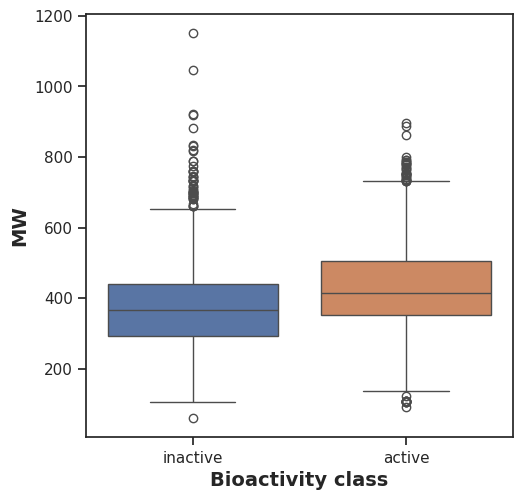

In [84]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('boxplot_MW.pdf')

log P

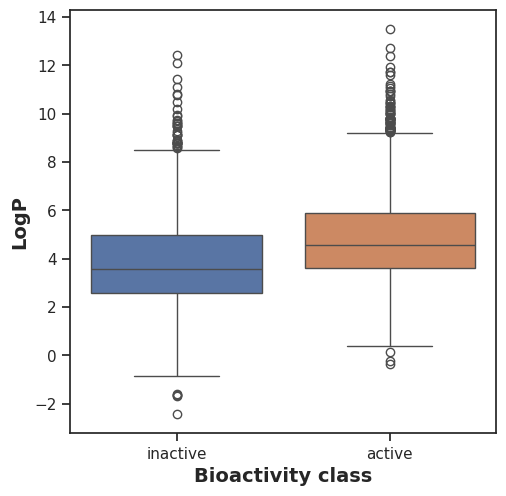

In [85]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = 'LogP', data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('boxplot_LogP.pdf')

NumHDonors

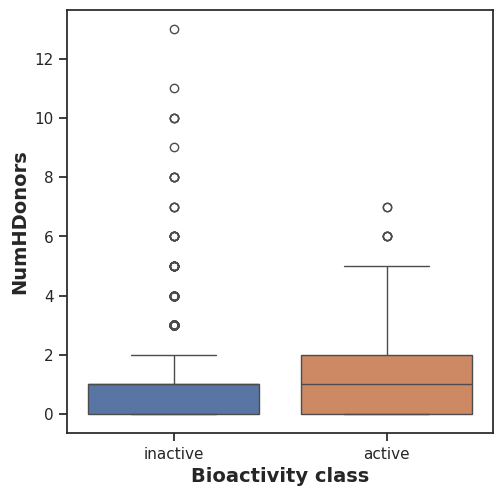

In [86]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = "NumHDonors", data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('boxplot_NumHDonors.pdf')

NumHAcceptors

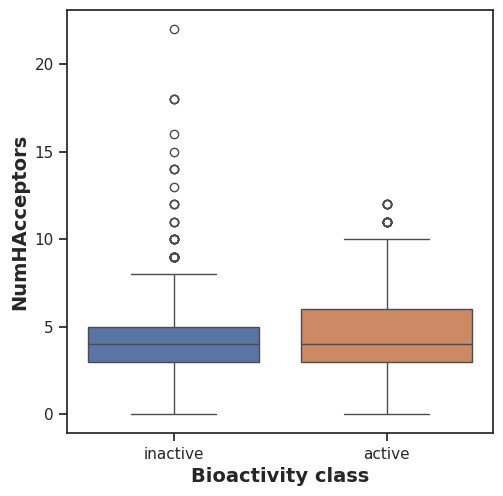

In [87]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = "NumHAcceptors", data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('boxplot_NumHAcceptors.pdf')


Save and Download the result

In [88]:
! zip -r EDA_results.zip . -i *df_lipinski.csv *mannwhitney_summary.csv *.pdf

  adding: boxplot_MW.pdf (deflated 37%)
  adding: barplot_bioactivity_class.pdf (deflated 38%)
  adding: boxplot_NumHDonors.pdf (deflated 38%)
  adding: scatter_plot_MW_vs_LogP.pdf (deflated 2%)
  adding: df_lipinski.csv (deflated 76%)
  adding: boxplot_NumHAcceptors.pdf (deflated 39%)
  adding: mannwhitney_summary.csv (deflated 50%)
  adding: boxplot_LogP.pdf (deflated 36%)
  adding: histogram_pic50.pdf (deflated 49%)


**Part 3: Descriptor Calculation**

PaDELPy is a Python wrapper for the PaDEL-Descriptor (molecular descriptor calculation) software.

It provide the following descriptors/fingerprint:

1444 - 2D Descriptors

431 - 3D Descriptors

881 bits - PubChem Fingerprints

Install PaDELpy

In [89]:
!pip install padelpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 60.5 MB/s eta 0:00:00


Import libraries

In [90]:
import pandas as pd
import numpy as np
from google.colab import files
from padelpy import padeldescriptor

Load dataset

In [91]:

df = pd.read_csv('df_lipinski.csv')
df.head()


,molecule_chembl_id,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL3754585,inactive,3.958607,BrCC1CN=C(Nc2ccccn2)S1,272.171,2.35980,1.0,4.0
1,CHEMBL5396497,active,8.154902,CC[N+](CC)(CCCCCn1c(=O)cc(C)n(CCCn2c(C)cc(=O)n...,583.710,2.71284,0.0,6.0
2,CHEMBL5431573,active,7.105130,Brc1ccc(-c2csc(/C=C/c3ccccc3)n2)cc1,342.261,5.74300,0.0,2.0
3,CHEMBL4779999,active,7.130768,Brc1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1,386.253,3.22070,0.0,6.0
4,CHEMBL4519496,active,6.602060,Brc1ccc(-c2nnn3c2C2c4ccccc4CCN2Cc2ccccc2-3)cc1,443.348,5.15790,0.0,3.0


In [92]:
data = df[['canonical_smiles', 'molecule_chembl_id']]
data.head()

,canonical_smiles,molecule_chembl_id
0,BrCC1CN=C(Nc2ccccn2)S1,CHEMBL3754585
1,CC[N+](CC)(CCCCCn1c(=O)cc(C)n(CCCn2c(C)cc(=O)n...,CHEMBL5396497
2,Brc1ccc(-c2csc(/C=C/c3ccccc3)n2)cc1,CHEMBL5431573
3,Brc1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1,CHEMBL4779999
4,Brc1ccc(-c2nnn3c2C2c4ccccc4CCN2Cc2ccccc2-3)cc1,CHEMBL4519496


Convert to .smi format

In [93]:
df_smi = data['canonical_smiles'].to_csv('smiles_chembl.smi', index=None, header=None)


In [94]:
! cat smiles_chembl.smi | head

BrCC1CN=C(Nc2ccccn2)S1
CC[N+](CC)(CCCCCn1c(=O)cc(C)n(CCCn2c(C)cc(=O)n(C)c2=O)c1=O)Cc1ccccc1[N+](=O)[O-]
Brc1ccc(-c2csc(/C=C/c3ccccc3)n2)cc1
Brc1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1
Brc1ccc(-c2nnn3c2C2c4ccccc4CCN2Cc2ccccc2-3)cc1
Brc1ccc(-n2cc(COc3ccc(/C=N/Nc4c5c(nc6ccccc46)CCCC5)cc3)nn2)cc1
Brc1ccc(/C=C2/CNCC3=C2N=C2SC=C(c4ccc5ccccc5c4)N2C3c2ccc(Br)cc2)cc1
Brc1ccc(CN2CCN(c3nccc(NCc4ccccc4)n3)CC2)cc1
Brc1ccc(CNC2CCN(Cc3ccccc3)C2)cc1
Brc1ccc(Cn2cc(CNC34CC5CC(CC(C5)C3)C4)nn2)cc1


Calculate molecular Pubchem Fingerprints using "padeldescriptor" function

In [95]:
padeldescriptor(mol_dir= "smiles_chembl.smi",
                d_file='pubchem_fingerprints.csv',
                fingerprints = True,
                retainorder= True,
                #removesalt = True, standardizetautomers = True, standardizenitro=True
                )

In [96]:
!ls -lh pubchem_fingerprints.csv

-rw-r--r-- 1 root root 8.4M Mar 29 10:32 pubchem_fingerprints.csv


In [97]:
df_fingerprint = pd.read_csv("pubchem_fingerprints.csv")
df_fingerprint.head()

,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,AUTOGEN_smiles_chembl_1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AUTOGEN_smiles_chembl_2,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,AUTOGEN_smiles_chembl_3,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,AUTOGEN_smiles_chembl_4,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AUTOGEN_smiles_chembl_5,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Prepare Dataset for ML

In [98]:
df.head()

,molecule_chembl_id,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL3754585,inactive,3.958607,BrCC1CN=C(Nc2ccccn2)S1,272.171,2.35980,1.0,4.0
1,CHEMBL5396497,active,8.154902,CC[N+](CC)(CCCCCn1c(=O)cc(C)n(CCCn2c(C)cc(=O)n...,583.710,2.71284,0.0,6.0
2,CHEMBL5431573,active,7.105130,Brc1ccc(-c2csc(/C=C/c3ccccc3)n2)cc1,342.261,5.74300,0.0,2.0
3,CHEMBL4779999,active,7.130768,Brc1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1,386.253,3.22070,0.0,6.0
4,CHEMBL4519496,active,6.602060,Brc1ccc(-c2nnn3c2C2c4ccccc4CCN2Cc2ccccc2-3)cc1,443.348,5.15790,0.0,3.0


In [99]:
# Select only the columns we need for ML
meta_cols = df[['molecule_chembl_id', 'bioactivity_class', 'pIC50']]

# Reset index to ensure proper alignment
meta_cols = meta_cols.reset_index(drop=True)
df_fingerprint = df_fingerprint.reset_index(drop=True)

# Combine meta data with fingerprints
combined_df = pd.concat([meta_cols, df_fingerprint.drop(df_fingerprint.columns[0], axis=1)], axis=1)

# Inspect the first few rows
combined_df.head()


,molecule_chembl_id,bioactivity_class,pIC50,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,CHEMBL3754585,inactive,3.958607,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CHEMBL5396497,active,8.154902,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CHEMBL5431573,active,7.105130,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CHEMBL4779999,active,7.130768,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CHEMBL4519496,active,6.602060,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Save and download the dataset

In [100]:
# Save as CSV
combined_df.to_csv("QSAR_dataset.csv", index=False)
print("Combined dataset saved as QSAR_dataset.csv")

# Download file in Colab
files.download("QSAR_dataset.csv")

Combined dataset saved as QSAR_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Calculate other fingerprints

Download xml Files from Github


In [102]:
!wget https://github.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/raw/main/padel_descriptors_xml.zip

--2026-03-29 10:41:30--  https://github.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/raw/main/padel_descriptors_xml.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/main/padel_descriptors_xml.zip [following]
--2026-03-29 10:41:30--  https://raw.githubusercontent.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/main/padel_descriptors_xml.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10871 (11K) [application/zip]
Saving to: ‘padel_descriptors_xml.zip.1’

padel_descriptors_x 100%[===========

Unzip all files

In [103]:
!unzip padel_descriptors_xml.zip

Archive:  padel_descriptors_xml.zip
  inflating: AtomPairs2DFingerprintCount.xml  
  inflating: AtomPairs2DFingerprinter.xml  
  inflating: EStateFingerprinter.xml  
  inflating: ExtendedFingerprinter.xml  
  inflating: Fingerprinter.xml       
  inflating: GraphOnlyFingerprinter.xml  
  inflating: KlekotaRothFingerprintCount.xml  
  inflating: KlekotaRothFingerprinter.xml  
  inflating: MACCSFingerprinter.xml  
  inflating: PubchemFingerprinter.xml  
  inflating: SubstructureFingerprintCount.xml  
  inflating: SubstructureFingerprinter.xml  


Calculate Fingerprints

In [106]:
# Specify the XML file for SubstructureFingerprinter directly
Substruc_fp = "SubstructureFingerprinter.xml"

# Calculate Substructure fingerprints
padeldescriptor(
    mol_dir='smiles_chembl.smi',
    d_file='Substructure_fingerprints.csv',
    fingerprints=True,
    descriptortypes= Substruc_fp,
    retainorder=True
    # removesalt=True, standardizetautomers=True
)


Random forest Regression model

In [107]:
# Install LazyPredict
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 5.3 MB/s eta 0:00:00


In [108]:
# Install SHAP
!pip install shap


In [109]:
# Import libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.utils import shuffle
from lazypredict.Supervised import LazyRegressor
import shap

Loading the Dataset

In [110]:
df = pd.read_csv('QSAR_dataset.csv')
df.head()

,molecule_chembl_id,bioactivity_class,pIC50,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,CHEMBL3754585,inactive,3.958607,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CHEMBL5396497,active,8.154902,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CHEMBL5431573,active,7.105130,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CHEMBL4779999,active,7.130768,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CHEMBL4519496,active,6.602060,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Features (X) and Target (y)

In [111]:

# Exclude non-feature columns
non_feature_cols = ['molecule_chembl_id', 'bioactivity_class', 'pIC50']
X = df.drop(columns=non_feature_cols)
print(X.shape)


(4894, 881)


In [112]:
# Target variable
y_reg = df['pIC50']
y_reg

,pIC50
0,3.958607
1,8.154902
2,7.105130
3,7.130768
4,6.602060
...,...
4889,6.307153
4890,6.575118
4891,6.490797
4892,6.304518


Feature Selection – Variance Threshold

In [113]:
# Apply variance threshold
selection = VarianceThreshold(threshold=(0.8*(1-0.8)))  # Threshold = 0.16
X_var = selection.fit_transform(X)

# Extract the correct feature names
selected_mask = selection.get_support()
feature_names = X.columns[selected_mask]

# Convert immediately to DataFrame
X_var = pd.DataFrame(X_var, columns=feature_names)

print('After variance threshold:', X_var.shape)

After variance threshold: (4894, 146)


In [116]:
881-146

735

Split Data into Training and Test Set

In [114]:
# Split into 80/20 train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_var, y_reg, test_size=0.2, random_state=123
)
print(f'Training set size: {X_train_reg.shape[0]} molecules')
print(f'Testing set size: {X_test_reg.shape[0]} molecules')

Training set size: 3915 molecules
Testing set size: 979 molecules


Build and Train Random Forest Model

In [115]:
# Set random seed for reproducibility
np.random.seed(123)

# Create Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=200)

# Train model
rf_model.fit(X_train_reg, y_train_reg)

RandomForestRegressor(n_estimators=200)

Evaluate Model's Performance on Test Set

In [117]:

r2 = rf_model.score(X_test_reg, y_test_reg)
print(f'Random Forest R² score: {r2:.4f}')

Random Forest R² score: 0.6832


R² interpretation:

R² < 0.4 → Poor fit.

R² < 0.5-0.7 → Moderate/Acceptable.

R² > 0.9 → Very good/High fit

Other metrics like RMSE or MAE can also be used.

Make Predictions on test set

In [118]:
# Predict on test set
y_pred_reg = rf_model.predict(X_test_reg)

In [119]:
y_pred_reg

array([4.50444597, 4.7060242 , 4.        , 6.95983671, 4.74632669,
       7.04679921, 5.22080359, 6.1060652 , 7.81096594, 8.08951255,
       7.85748758, 6.3079346 , 7.09619547, 6.37365549, 4.14228636,
       7.08772063, 4.65905008, 5.37201965, 3.66489335, 4.1395201 ,
       7.6917302 , 6.45183779, 4.4530102 , 4.2060075 , 8.25610845,
       4.87670374, 5.38142292, 5.63667687, 4.65749696, 5.69502318,
       7.57753505, 4.77413446, 6.76411053, 4.53509315, 7.15961535,
       4.92625421, 7.21608486, 4.70643994, 5.58105597, 4.95552223,
       5.2497604 , 5.12852924, 7.90322736, 5.        , 6.1567804 ,
       7.79167355, 6.42657597, 5.56205158, 6.06810476, 4.35060765,
       4.05053452, 4.37127111, 4.61147546, 6.15419498, 6.24422796,
       6.95226999, 4.50669417, 8.35597311, 5.99229457, 6.70147668,
       6.5501207 , 4.49538877, 7.51742031, 8.16774332, 4.95381085,
       7.37665965, 4.61010477, 5.8652674 , 3.70753166, 8.16774332,
       6.18054332, 6.37772505, 7.47708709, 5.71666104, 6.12156

y_test_reg ..............# actual pIC50
y_pred_reg ..............# predicted pIC50 values from model


Visualize Predictions vs Actual Values

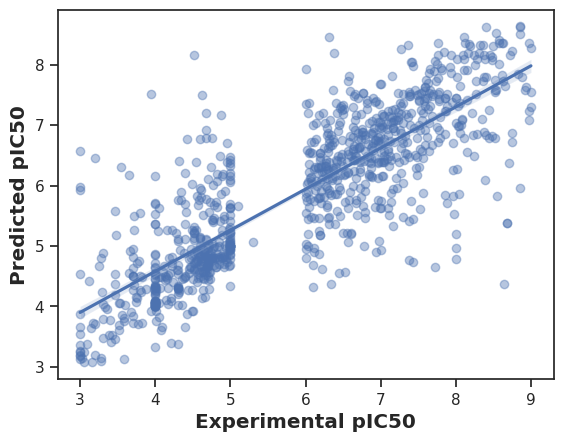

In [120]:
ax = sns.regplot(x=y_test_reg, y=y_pred_reg, scatter_kws={'alpha':0.4})
ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
plt.show()

Y-Randomization – Validate Model

In [121]:
n_iterations = 5
random_r2_scores = []

for i in range(n_iterations):
    y_train_shuffled = shuffle(y_train_reg, random_state=i)
    rf_random = RandomForestRegressor(n_estimators=200, random_state=42)
    rf_random.fit(X_train_reg, y_train_shuffled)
    y_pred_random = rf_random.predict(X_test_reg)
    r2_random = r2_score(y_test_reg, y_pred_random)
    random_r2_scores.append(r2_random)

print('\nY-Randomization Test Results:')
print(f'Mean R² with shuffled Y: {np.mean(random_r2_scores):.4f}')
print(f'Actual RF R²: {r2:.4f}')


Y-Randomization Test Results:
Mean R² with shuffled Y: -0.1967
Actual RF R²: 0.6832


Interpretation:

Actual RF R² = 0.5,

Random R² ≈ -0.2 → Model is learning real chemical patterns, not noise.

LazyPredict – Compare Multiple Regression Models

In [123]:
print('\n' + '='*60)
print('LAZYPREDICT - COMPARING MULTIPLE REGRESSION MODELS')
print('='*60)

# Initialize LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)

# Fit all models
models, predictions = reg.fit(X_train_reg, X_test_reg, y_train_reg, y_test_reg)

# Display results
print(models.head(10))  # Top 10 models


LAZYPREDICT - COMPARING MULTIPLE REGRESSION MODELS
                               Adjusted R-Squared  R-Squared      RMSE  \
Model                                                                    
RandomForestRegressor                    0.627835   0.683394  0.875140   
XGBRegressor                             0.619102   0.675964  0.885349   
BaggingRegressor                         0.604267   0.663344  0.902425   
HistGradientBoostingRegressor            0.587137   0.648771  0.921749   
LGBMRegressor                            0.564832   0.629796  0.946321   
MLPRegressor                             0.537798   0.606798  0.975272   
SVR                                      0.533711   0.603321  0.979575   
NuSVR                                    0.521078   0.592574  0.992756   
KNeighborsRegressor                      0.512144   0.584973  1.001973   
ExtraTreesRegressor                      0.440153   0.523729  1.073358   

                               Time Taken  
Model          

Visualize Top Models

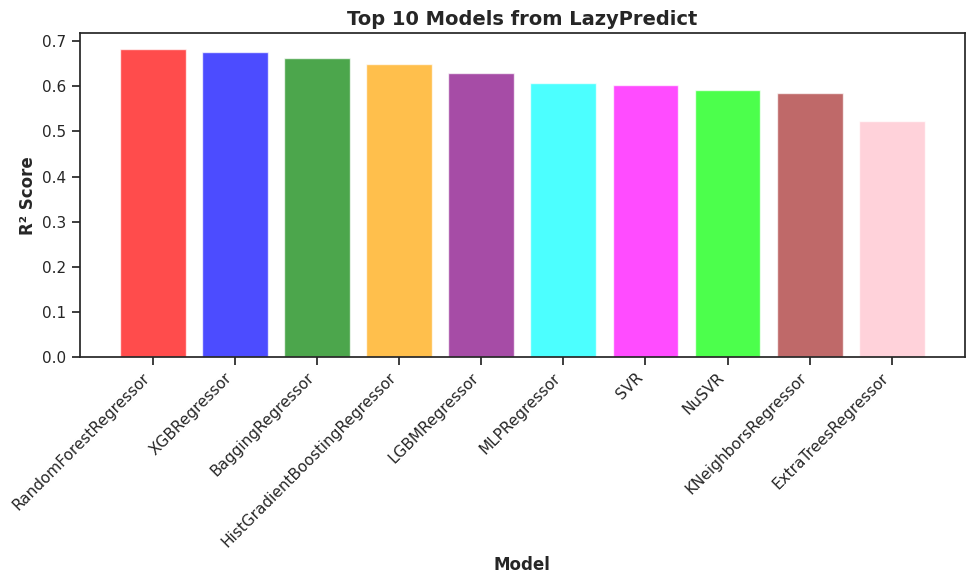

In [124]:
top_models = models.head(10)

plt.figure(figsize=(10, 6))

# Define distinct colors for each bar
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'lime', 'brown', 'pink']

# Vertical bar plot with multiple colors and alpha for transparency
plt.bar(top_models.index, top_models['R-Squared'], color=colors, alpha=0.7)

plt.ylabel('R² Score', fontsize=12, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.title('Top 10 Models from LazyPredict', fontsize=14, fontweight='bold')

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Compare Best Model with Random Forest

In [125]:

best_model_name = models.index[0]
best_r2 = models['R-Squared'].iloc[0]
print(f'Best model from LazyPredict: {best_model_name}')
print(f'Best R² score: {best_r2:.4f}')
print(f'Random Forest R²: {r2:.4f}')
print(f'Improvement: {(best_r2 - r2)*100:.2f}%')

# Check Random Forest rank
if 'RandomForestRegressor' in models.index:
    rf_rank = models.index.get_loc('RandomForestRegressor') + 1
    print(f'Random Forest ranked: {rf_rank} out of {len(models)}')

Best model from LazyPredict: RandomForestRegressor
Best R² score: 0.6834
Random Forest R²: 0.6832
Improvement: 0.02%
Random Forest ranked: 1 out of 42


Random Forest Feature Importances using SHAP values

/tmp/ipykernel_6666/1758221937.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_reg, feature_names= feature_names)


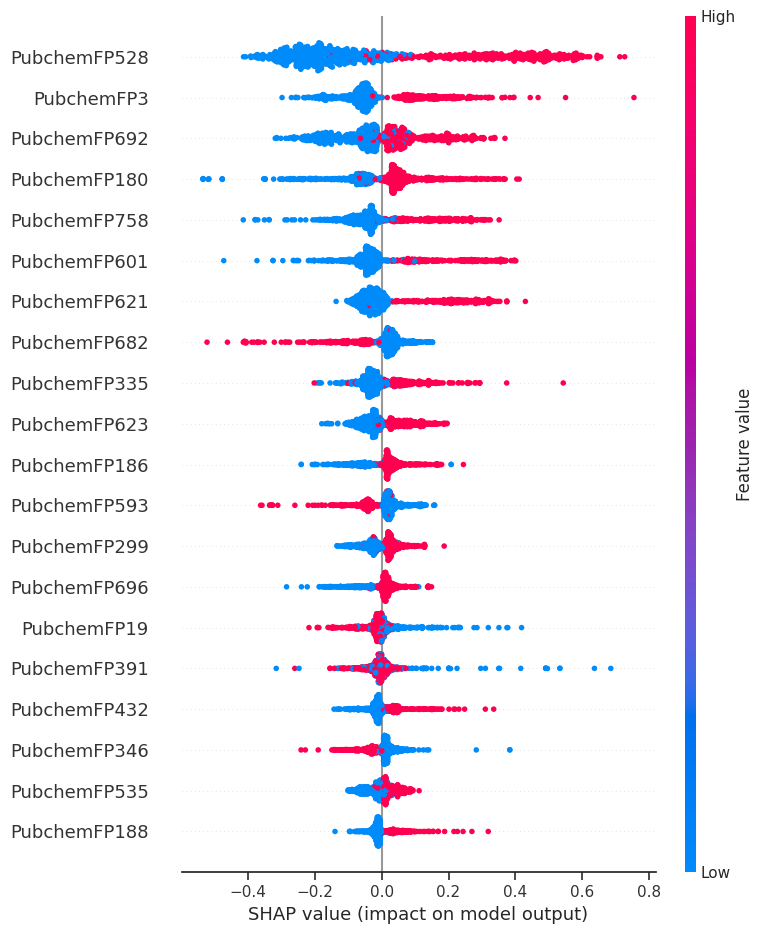

In [126]:
# Create an explainer and calculate SHAP values for the test set
explainer = shap.Explainer(rf_model)
shap_values=[] = explainer(X_test_reg)

# Summary plot
shap.summary_plot(shap_values, X_test_reg, feature_names= feature_names)